In [59]:
%load_ext autoreload
%autoreload 2
from src import datasets
from src.utils.io_utils import ROOT_PATH
import numpy as np
from src.datasets.musdb_utils import get_number_of_possible_segments
from src.datasets.musdb_utils import divide_into_segments

data = datasets.MusDB(subsets='train')
data[0]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Preparing musdb folders: train: 0it [00:00, ?it/s]


IndexError: list index out of range

In [1]:
%load_ext autoreload
%autoreload 2

import musdb
import dotenv

dotenv.load_dotenv()

mus_train = musdb.DB(subsets='train', download=False)
#mus_test = musdb.DB(subsets='test', download=False)

mus_train[0].audio.shape

(7552000, 2)

In [3]:
for item in mus_train[0].targets:
    print(item)

vocals
drums
bass
other
accompaniment
linear_mixture


In [4]:
mus_train[0]

A Classic Education - NightOwl

In [12]:
from src.datasets.musdb_dataset_sigsep import MusDBSigSep

musdb_dataset = MusDBSigSep(mus_train)
elem_sigsep = musdb_dataset[1]
elem_sigsep

{'sources_segments_spectrograms': tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           ...,
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00]],
 
          [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           ...,
     

In [10]:
elem_sigsep['sources_segments_spectrograms'].shape

torch.Size([119, 6, 1025, 63])

In [6]:
elem_sigsep['mixture_segments_spectrograms'].shape

torch.Size([119, 1025, 173])

In [15]:
data[0]['mixture_segments_spectrograms'].shape

torch.Size([84, 128, 161])

In [16]:
element = data[0]
element['mixture_segments_spectrograms'].shape

torch.Size([84, 128, 161])

In [ ]:
data[95]['mixture_segments_spectrograms'].shape

torch.Size([99, 128, 161])

In [15]:
element['mixture_audio'].shape

torch.Size([1, 4855014])

In [17]:
element['mixture_segments_audio'].shape

torch.Size([84, 32000])

In [21]:
element['source_audios'][0].shape

torch.Size([1, 4855014])

In [ ]:
element['source_segments_spectrograms'].shape

torch.Size([152, 4, 128, 161])

In [9]:
# Test segments split
from src.datasets.musdb_utils import divide_into_segments
import torch

segments = divide_into_segments(torch.tensor(mus_train[1].audio[:,0]).unsqueeze(0))
len(segments)

25856
32000


328

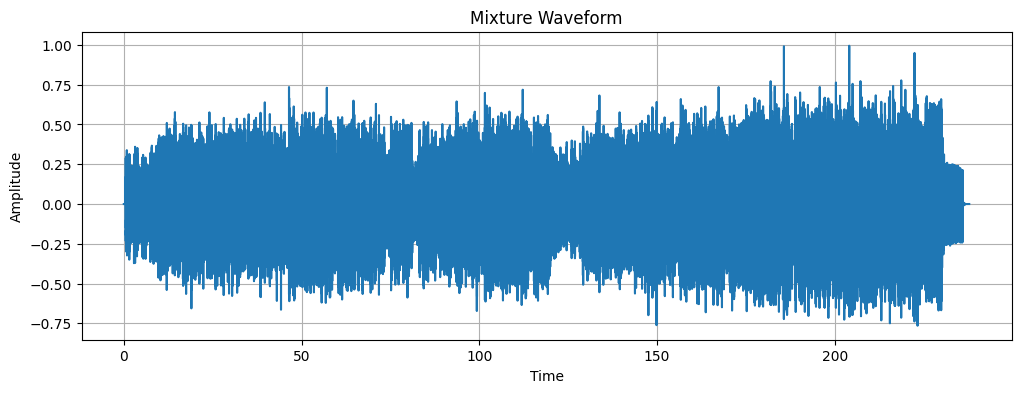

In [ ]:
from IPython import display
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(waveform, title="Waveform", xlim=None, ylim=None):
    sample_rate = 44100
    time_axis = np.arange(0, waveform.shape[1]) / sample_rate

    plt.figure(figsize=(12, 4))
    plt.title(title)
    plt.plot(time_axis, waveform[0])
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

    display.display(display.Audio(waveform, rate=sample_rate, normalize=False))

plot_waveform(elem_sigsep['mixture_audio'], title="Mixture Waveform")

In [3]:
from src.datasets.musdb_segments_dataset import MusDB_segments

data_segments = MusDB_segments(musdb_dataset[0])
mix_segm, source_segm = data_segments[0]
source_segm.shape

torch.Size([1025, 173])

In [11]:
len(data_segments)

236

In [4]:
def data_generation(data):
  items = []
  for i in range(len(data)):
    print(f"Get {i} item")
    item = MusDB_segments(data[i])
    items.append(item)
    if i == 5:
      break
  return items

songs = data_generation(musdb_dataset)

Get 0 item
Get 1 item
Get 2 item
Get 3 item
Get 4 item
Get 5 item


In [ ]:
import pickle

# save
with open("songs.pkl", "wb") as f:
    pickle.dump(songs, f)

# later load
with open("songs.pkl", "rb") as f:
    songs = pickle.load(f)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

def plot_losses(train_losses): 
    clear_output()
    plt.figure()
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.title(f'Loss curve')
    plt.show()

Starting training for 5 epochs...


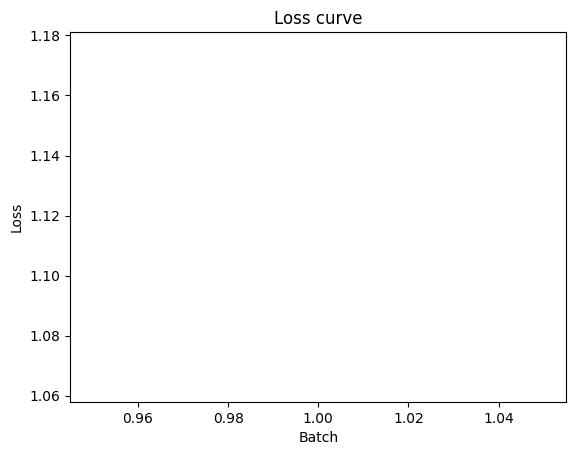

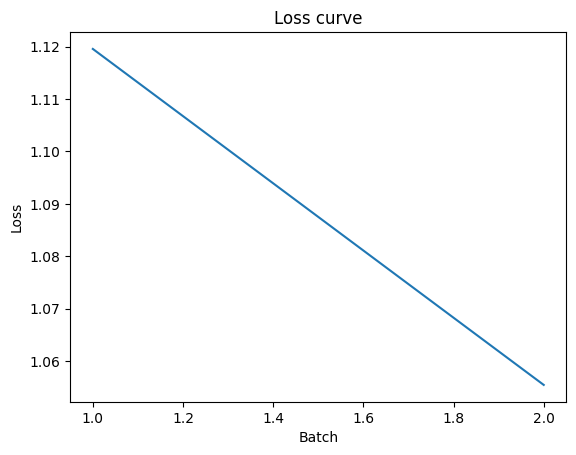

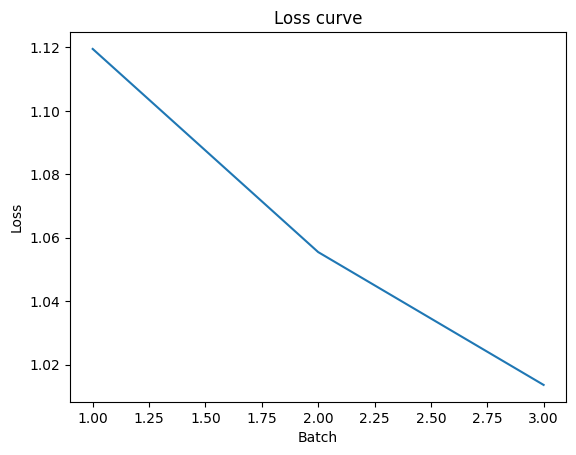

KeyboardInterrupt: 

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from src.model.mss_unet3 import StandardSeparationUNet

def train_standard_unet(model, songs_dataset, epochs=1, batch_size=4):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    criterionL1 = nn.L1Loss()
    
    train_losses = []

    print(f"Starting training for {epochs} epochs...")
    for epoch in range(epochs):
        losses = []
        for song in songs_dataset:
            dataloader = DataLoader(song, batch_size=batch_size, shuffle=False)
            
            for i, (mixture_batch, sources_batch) in enumerate(dataloader):
                # In this simple dataset, each 'batch' is the entire dataset once
                # mixture is [1, 1, freq, time], true_sources is [n_sources, freq, time]
                #print(mixture_batch.shape)
                mixture_input = mixture_batch.unsqueeze(1) # [B, 1, F, T]
                true_sources = sources_batch.unsqueeze(1) # [B, n, F, T]
                
                #print(f"True {true_sources.shape}")
                # ПРЯМОЙ ПРОХОД: смесь -> источники
                predicted_sources = model(mixture_input) # [B, n_sources, freq, time]
                #print(f"Pred {predicted_sources.shape}")
                # СРАВНЕНИЕ с истинными источниками
                loss = criterionL1(predicted_sources, true_sources)
                
                # ОБРАТНЫЙ ПРОХОД
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                losses.append(loss.item())

                if i % 10 == 0: # Print loss for every batch
                    print(f"Epoch [{epoch+1}/{epochs}], Batch [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")
        
        # Plot after each epoch
        train_losses += [np.mean(losses)]
        plot_losses(train_losses)
    
    print("Training finished.")

# Model initialization
model = StandardSeparationUNet(n_sources=1)

#data_segments = MusDB_segments(elem_sigsep)
# Train the model
train_standard_unet(model, songs, epochs=5)

In [37]:
import torchaudio

audio = element['mixture_audio']
spectrogram_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000)
spectrogram_audio = spectrogram_transform(audio)

In [38]:
spectrogram_audio.shape

torch.Size([1, 128, 13345])

In [ ]:
pred = model(spectrogram_audio).unsqueeze(0)

torch.Size([64, 128, 13345])
torch.Size([128, 64, 6673])
torch.Size([256, 32, 3337])
bottlenec torch.Size([512, 32, 3337])
dec1 torch.Size([256, 32, 3337])
dec2 torch.Size([128, 64, 6673])
dec3 torch.Size([64, 128, 13345])
output torch.Size([4, 128, 13345])


tensor([[[[0.5027, 0.4739, 0.4906,  ..., 0.4899, 0.4799, 0.5018],
          [0.4652, 0.4369, 0.4284,  ..., 0.4232, 0.4374, 0.4637],
          [0.4863, 0.4302, 0.4509,  ..., 0.4510, 0.4236, 0.4837],
          ...,
          [0.4726, 0.4425, 0.4443,  ..., 0.4405, 0.4397, 0.4715],
          [0.4978, 0.4663, 0.4738,  ..., 0.4742, 0.4550, 0.4960],
          [0.4949, 0.4767, 0.4718,  ..., 0.4687, 0.4686, 0.4939]],

         [[0.4923, 0.4607, 0.4888,  ..., 0.4881, 0.4716, 0.4921],
          [0.4612, 0.4271, 0.4331,  ..., 0.4333, 0.4399, 0.4583],
          [0.4841, 0.4113, 0.4591,  ..., 0.4602, 0.4268, 0.4837],
          ...,
          [0.4702, 0.4401, 0.4478,  ..., 0.4477, 0.4445, 0.4683],
          [0.4924, 0.4423, 0.4747,  ..., 0.4758, 0.4439, 0.4923],
          [0.4846, 0.4656, 0.4748,  ..., 0.4738, 0.4809, 0.4851]],

         [[0.4739, 0.4470, 0.4655,  ..., 0.4643, 0.4442, 0.4724],
          [0.4399, 0.4153, 0.3815,  ..., 0.3797, 0.3947, 0.4393],
          [0.4589, 0.3988, 0.4469,  ..., 0